              WTI  Gasoline  HeatingOil
DATE                                   
2026-08-12  84.97     3.158       4.185
2026-08-13  82.77     3.130       4.155
2026-08-14  83.99     3.192       4.172
2026-08-17  86.04     3.324       4.352
2026-08-18  86.48     3.361       4.370


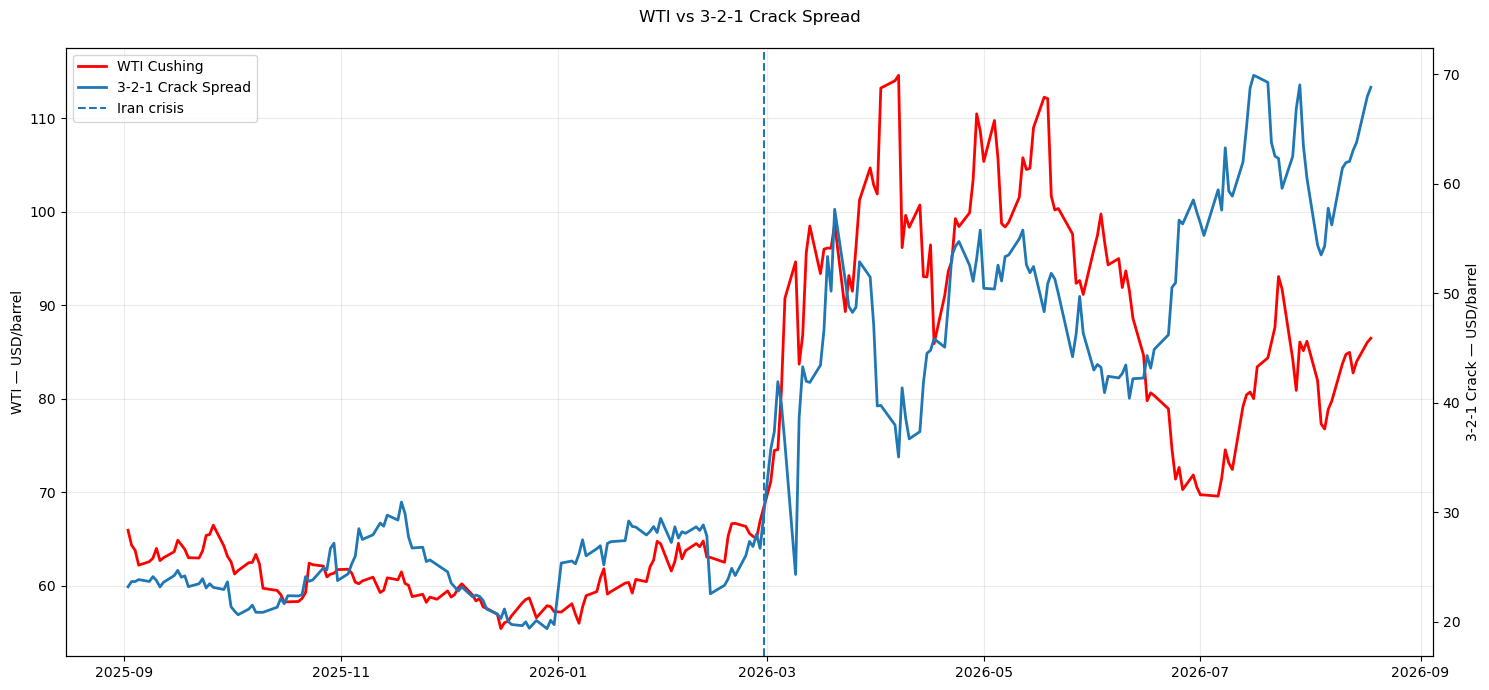

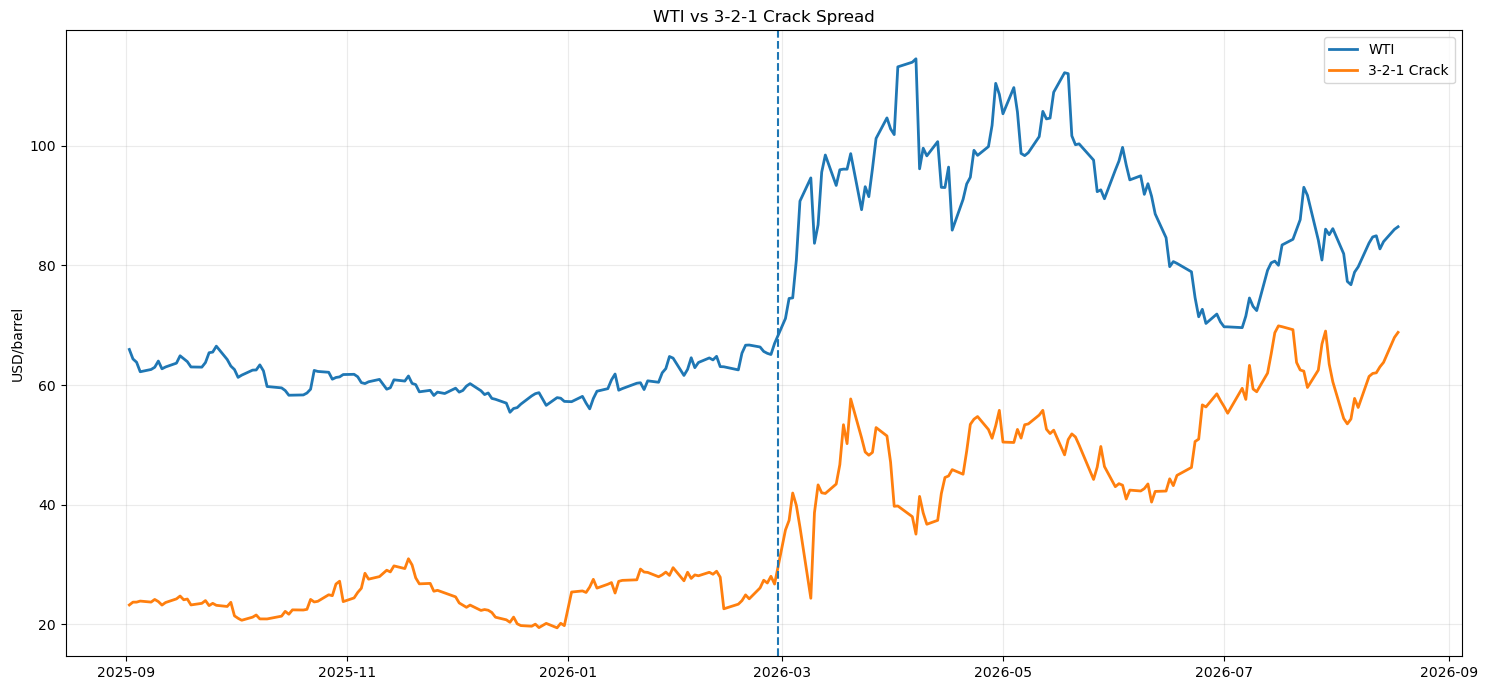

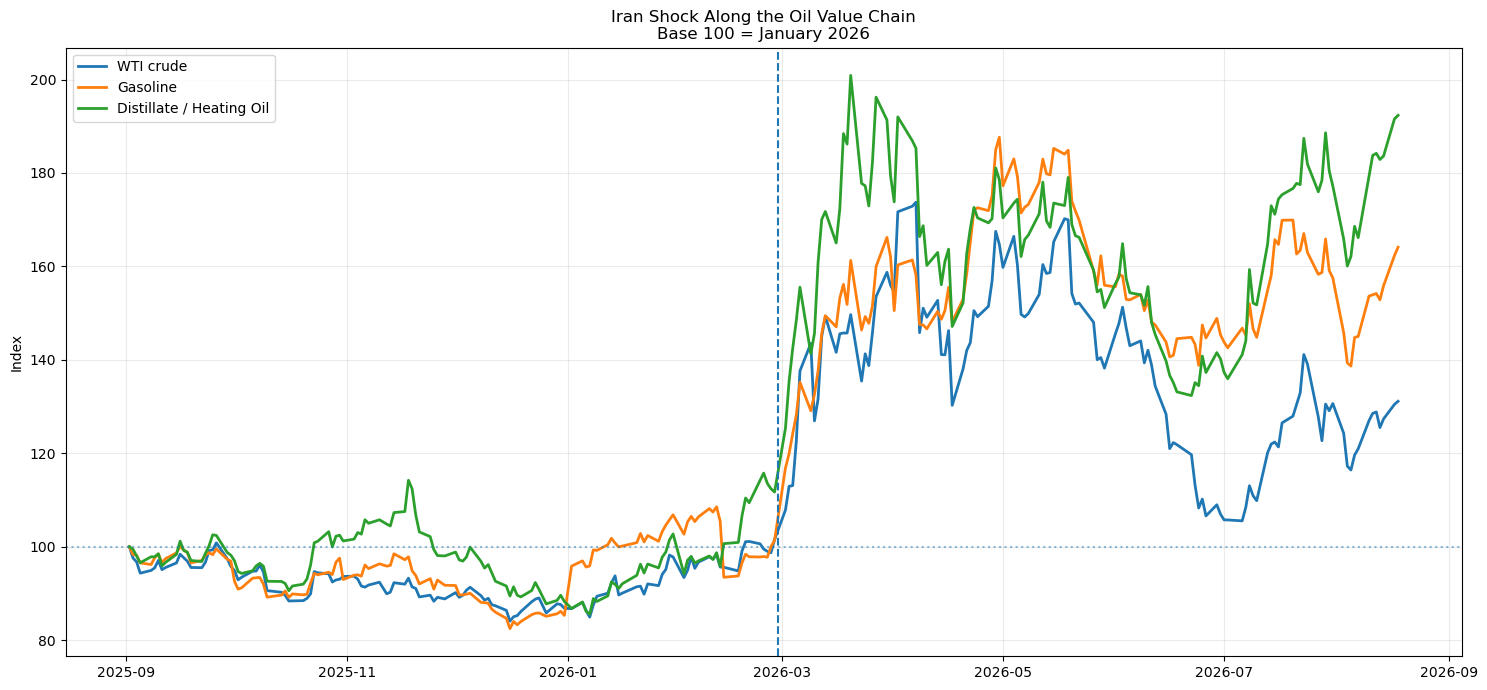


Maximum 3-2-1 crack spread:
DATE
2026-07-16    69.896
2026-07-17    69.758
2026-07-20    69.256
2026-07-29    69.026
2026-08-18    68.808
2026-07-15    68.748
2026-08-17    67.960
2026-07-28    66.846
2026-07-14    65.216
2026-08-14    63.794
2026-07-21    63.774
2026-07-30    63.502
2026-07-08    63.284
2026-08-13    63.040
2026-07-22    62.518
Name: Crack321, dtype: float64

Latest observations:
              WTI  Crack321
DATE                       
2026-08-05  76.78    54.316
2026-08-06  78.88    57.760
2026-08-07  79.77    56.240
2026-08-10  83.76    61.434
2026-08-11  84.77    61.936
2026-08-12  84.97    62.044
2026-08-13  82.77    63.040
2026-08-14  83.99    63.794
2026-08-17  86.04    67.960
2026-08-18  86.48    68.808


In [2]:
# ============================================================
# WTI vs 3-2-1 CRACK SPREAD
# Public daily EIA/FRED data
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

START_DATE = "2025-09-01"
EVENT_DATE = pd.Timestamp("2026-02-28")

# ------------------------------------------------------------
# 1. FRED CSV endpoints
# ------------------------------------------------------------

urls = {
    "WTI":
        "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILWTICO",

    "Gasoline":
        "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGASNYH",

    "HeatingOil":
        "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DHOILNYH"
}

# ------------------------------------------------------------
# 2. Download data
# ------------------------------------------------------------

series = {}

for name, url in urls.items():

    df = pd.read_csv(url)

    # FRED CSVs typically have 'observation_date' as the date column.
    # We rename it to 'DATE' for consistency with the rest of the code.
    if 'observation_date' in df.columns:
        df = df.rename(columns={'observation_date': 'DATE'})

    df["DATE"] = pd.to_datetime(df["DATE"])

    # FRED may use "." for missing observations
    df.iloc[:, 1] = pd.to_numeric(
        df.iloc[:, 1],
        errors="coerce"
    )

    df = df.rename(
        columns={
            df.columns[1]: name
        }
    )

    df = df.set_index("DATE")

    series[name] = df


# ------------------------------------------------------------
# 3. Merge
# ------------------------------------------------------------

prices = pd.concat(
    series.values(),
    axis=1
)

prices = prices.loc[START_DATE:].dropna()

print(prices.tail())


# ------------------------------------------------------------
# 4. Convert gasoline/distillate:
#    USD/gallon -> USD/barrel
#
#    1 barrel = 42 gallons
# ------------------------------------------------------------

prices["Gasoline_bbl"] = prices["Gasoline"] * 42

prices["HeatingOil_bbl"] = prices["HeatingOil"] * 42


# ------------------------------------------------------------
# 5. Calculate 3-2-1 crack spread
#
#    3 crude barrels
#       ->
#    2 gasoline barrels
#    1 distillate barrel
#
#    Spread expressed per barrel of crude
# ------------------------------------------------------------

prices["Crack321"] = (
      2 * prices["Gasoline_bbl"]
    + 1 * prices["HeatingOil_bbl"]
    - 3 * prices["WTI"]
) / 3


# ============================================================
# GRAPH 1
# WTI vs 3-2-1 CRACK
# ============================================================

fig, ax1 = plt.subplots(figsize=(15, 7))

# WTI
line1 = ax1.plot(
    prices.index,
    prices["WTI"],
    linewidth=2,
    color="red",
    label="WTI Cushing"
)

ax1.set_ylabel("WTI — USD/barrel")

# Crack on second axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    prices.index,
    prices["Crack321"],
    linewidth=2,
    label="3-2-1 Crack Spread"
)

ax2.set_ylabel("3-2-1 Crack — USD/barrel")

# Iran event
event_line = ax1.axvline(
    EVENT_DATE,
    linestyle="--",
    linewidth=1.5,
    label="Iran crisis"
)

# Combined legend
lines = line1 + line2 + [event_line]
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc="upper left"
)

plt.title(
    "WTI vs 3-2-1 Crack Spread\n"
)

ax1.grid(alpha=0.25)

fig.tight_layout()

plt.show()


# ============================================================
# GRAPH 2
# SAME AXIS — both already USD/barrel
# ============================================================

plt.figure(figsize=(15, 7))

plt.plot(
    prices.index,
    prices["WTI"],
    linewidth=2,
    label="WTI"
)

plt.plot(
    prices.index,
    prices["Crack321"],
    linewidth=2,
    label="3-2-1 Crack"
)

plt.axvline(
    EVENT_DATE,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "WTI vs 3-2-1 Crack Spread"
)

plt.ylabel("USD/barrel")

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 3
# VALUE CHAIN — BASE 100
# ============================================================

chain = prices[
    ["WTI", "Gasoline_bbl", "HeatingOil_bbl"]
].copy()

chain = chain / chain.iloc[0] * 100

plt.figure(figsize=(15, 7))

plt.plot(
    chain.index,
    chain["WTI"],
    linewidth=2,
    label="WTI crude"
)

plt.plot(
    chain.index,
    chain["Gasoline_bbl"],
    linewidth=2,
    label="Gasoline"
)

plt.plot(
    chain.index,
    chain["HeatingOil_bbl"],
    linewidth=2,
    label="Distillate / Heating Oil"
)

plt.axhline(
    100,
    linestyle=":",
    alpha=0.5
)

plt.axvline(
    EVENT_DATE,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Iran Shock Along the Oil Value Chain\n"
    "Base 100 = January 2026"
)

plt.ylabel("Index")

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()


# ============================================================
# 6. SIMPLE NUMERICAL CHECK
# ============================================================

print("\nMaximum 3-2-1 crack spread:")
print(
    prices["Crack321"]
    .sort_values(ascending=False)
    .head(15)
)

print("\nLatest observations:")
print(
    prices[
        ["WTI", "Crack321"]
    ].tail(10)
)
